In [ ]:
!pip install -q diffusers transformers accelerate opencv-python torch torchvision

import torch
import gc
from PIL import Image
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler, ControlNetModel, AutoencoderKL, StableDiffusionXLControlNetPipeline
import numpy as np
from transformers import pipeline
from google.colab import files

In [6]:
print("لطفاً عکس اتاق خود را آپلود کنید:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
original_image = Image.open(file_name).convert("RGB")
print("عکس با موفقیت آپلود شد.")

لطفاً عکس اتاق خود را آپلود کنید:


Saving your_room_image.jpg to your_room_image.jpg
عکس با موفقیت آپلود شد.


In [ ]:
gc.collect()
torch.cuda.empty_cache()

original_image = Image.open(file_name).convert("RGB")
init_image_512 = original_image.resize((512, 512))

در حال بارگذاری مدل InstructPix2Pix...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

در حال تولید تصویر...


  0%|          | 0/20 [00:00<?, ?it/s]

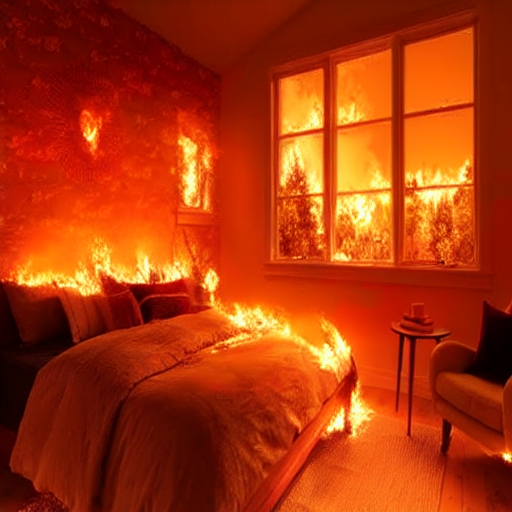

In [ ]:
print("در حال بارگذاری مدل InstructPix2Pix...")
pipe_instruct = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix",
    torch_dtype=torch.float16,
    safety_checker=None 
)
pipe_instruct.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_instruct.scheduler.config)
pipe_instruct.enable_model_cpu_offload()

prompt_instruct = "make the room look like a burning forest, realistic fire, flames, dramatic lighting"

print("در حال تولید تصویر...")
out_instruct = pipe_instruct(
    prompt_instruct,
    image=init_image_512,
    num_inference_steps=20,
    image_guidance_scale=1.5
).images[0]

display(out_instruct)

[transformers] No model was supplied, defaulted to Intel/dpt-large and revision bc15f29.
Using a pipeline without specifying a model name and revision in production is not recommended.


در حال استخراج نقشه عمق...


config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.37GB            

model.safetensors: downloading bytes:           |  0.00B            

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

در حال تولید تصویر با کیفیت بالا...


  0%|          | 0/25 [00:00<?, ?it/s]

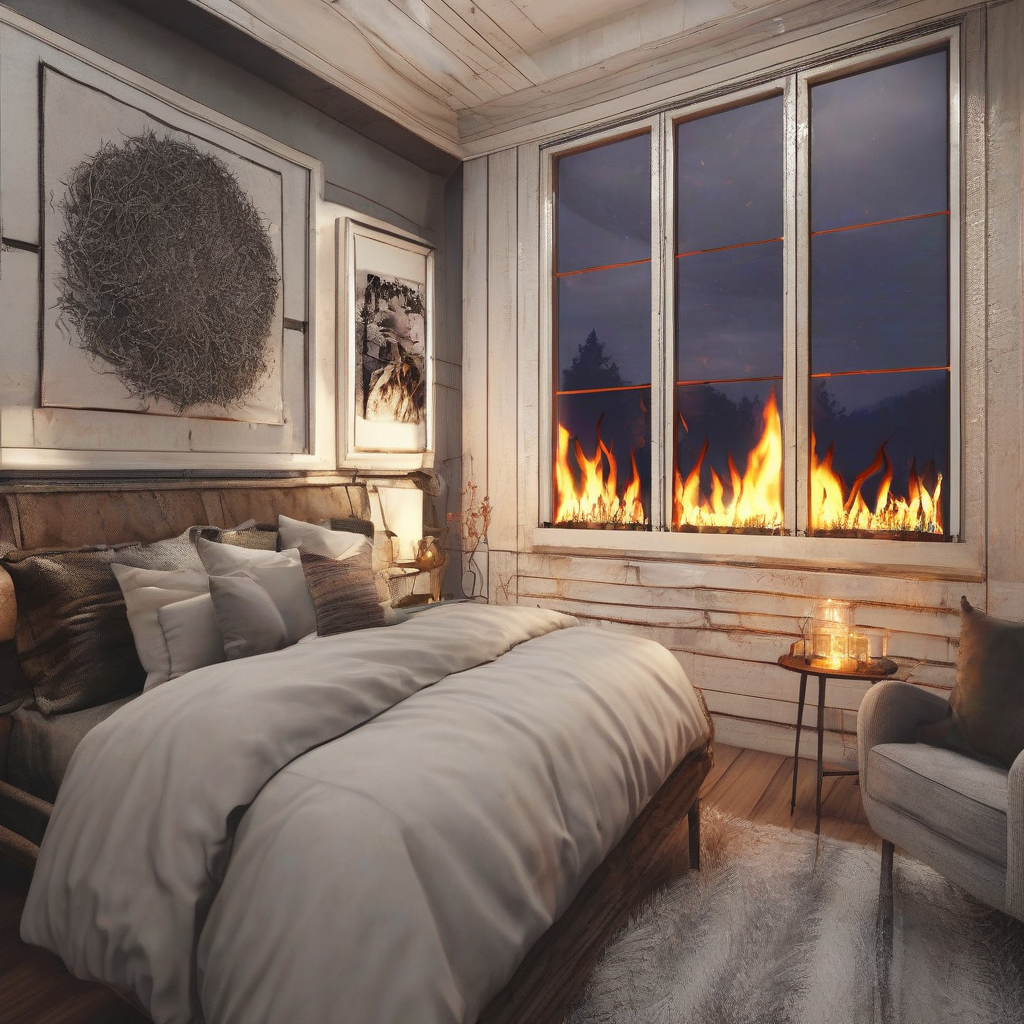

In [ ]:
gc.collect()
torch.cuda.empty_cache()

print("در حال استخراج نقشه عمق...")
depth_estimator = pipeline('depth-estimation')

def get_depth_map(image):
    image_depth = depth_estimator(image)['depth']
    image_depth = np.array(image_depth)
    image_depth = image_depth[:, :, None]
    image_depth = np.concatenate([image_depth, image_depth, image_depth], axis=2)
    return Image.fromarray(image_depth)

init_image_1024 = original_image.resize((1024, 1024))
depth_map_xl = get_depth_map(init_image_1024)

del depth_estimator
gc.collect()
torch.cuda.empty_cache()

print("در حال بارگذاری مدل‌های SDXL...")
controlnet_xl = ControlNetModel.from_pretrained(
    "diffusers/controlnet-depth-sdxl-1.0",
    torch_dtype=torch.float16
)
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix",
    torch_dtype=torch.float16
)
pipe_xl = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    controlnet=controlnet_xl,
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16", 
    use_safetensors=True
)
pipe_xl.enable_model_cpu_offload()
pipe_xl.enable_attention_slicing()

prompt_xl = "a highly detailed, photorealistic interior design, burning forest style, fire elements, dark walls, warm lighting, 8k"
negative_prompt_xl = "blurry, distorted, low quality, bad architecture, deformed"

print("در حال تولید تصویر با کیفیت بالا...")
out_xl = pipe_xl(
    prompt_xl,
    negative_prompt=negative_prompt_xl,
    image=depth_map_xl,
    num_inference_steps=25,
    controlnet_conditioning_scale=0.5
).images[0]

display(out_xl)